In [8]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import math

In [ ]:
file_path='your excel file path here'
"""Load and preprocess the data for model training."""
data_raw = pd.read_excel(file_path)

# Drop rows missing target or key features
required_columns = ['turnAroundDays', 'actualTime (min)', 'materialCode', 'quantity', 'orderDate']
data = data_raw.replace('-',np.nan)
data = data.dropna(subset='turnAroundDays')

if len(data) == 0:
    raise ValueError("No valid rows found after cleaning. Check your Excel data.")

# Convert orderDate to numeric days since first order
data['orderDate'] = pd.to_datetime(data['orderDate'], errors='coerce')

# Ensure numeric types for model
data['actualTime (min)'] = pd.to_numeric(data['actualTime (min)'], errors='coerce')
data['quantity'] = pd.to_numeric(data['quantity'], errors='coerce')
data['turnAroundDays'] = pd.to_numeric(data['turnAroundDays'], errors='coerce')

# Create Quarter feature
data['Quarter']=data['orderDate'].dt.quarter

# Convert categorical variables (materialCode, Quarter) into categorical
if data['Quarter'].dtype != 'category':
    data['Quarter'] = data['Quarter'].astype('category')
data[['materialType','materialc']]=data['materialCode'].str.split('-',expand=True)
if data['materialType'].dtype != 'category':
    data['materialType'] = data['materialType'].astype('category')

# Split into features and target
feature_cols = ['actualTime (min)', 'materialType', 'quantity',  'Quarter' ]
X = data[feature_cols]
y = data['turnAroundDays']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

leaves_ls = []
estimators_ls = []
train_ls = [] #[R2, MAE]
val_ls = []
oot_ls = []

R2_ls = [] #train, test
mae_ls = []

for num_leaves in np.arange(4, 5, 1):
    for num_boost in np.arange(20, 21, 5):

        leaves_ls.append(num_leaves)
        estimators_ls.append(num_boost)

        model = xgb.XGBRegressor(
                        objective = "reg:gamma",
                        eval_metric = 'gamma-nloglik',

                        max_leaves = num_leaves,
                        n_estimators = num_boost,
                        learning_rate = 0.1,
                        min_child_weight = 5,

                        enable_categorical=True
                    )

        xgb_model = model.fit(X_train, y_train)
        y_train_pred = xgb_model.predict(X_train)
        y_test_pred = xgb_model.predict(X_test)

        y_train_pred_round = y_train_pred.round()
        y_test_pred_round = y_test_pred.round()

        mae_train = mean_absolute_error(y_train, y_train_pred_round)
        r2_train = r2_score(y_train, y_train_pred_round)

        mae_test = mean_absolute_error(y_test, y_test_pred_round)
        r2_test = r2_score(y_test, y_test_pred_round)

        R2_ls.append([round(r2_train,4), round(r2_test,4)])
        mae_ls.append([round(mae_train,2), round(mae_test,2)])

results = pd.DataFrame(zip(leaves_ls, estimators_ls, R2_ls, mae_ls), columns=['leaves', 'estimators', 'R2', 'MAE'])
results

,leaves,estimators,R2,MAE
0,4,20,"[0.6853, 0.6007]","[0.73, 0.87]"


In [61]:
importance =pd.DataFrame(zip(xgb_model.feature_names_in_, xgb_model.feature_importances_))
importance

,0,1
0,actualTime (min),0.203946
1,materialType,0.533956
2,quantity,0.153845
3,Quarter,0.108253


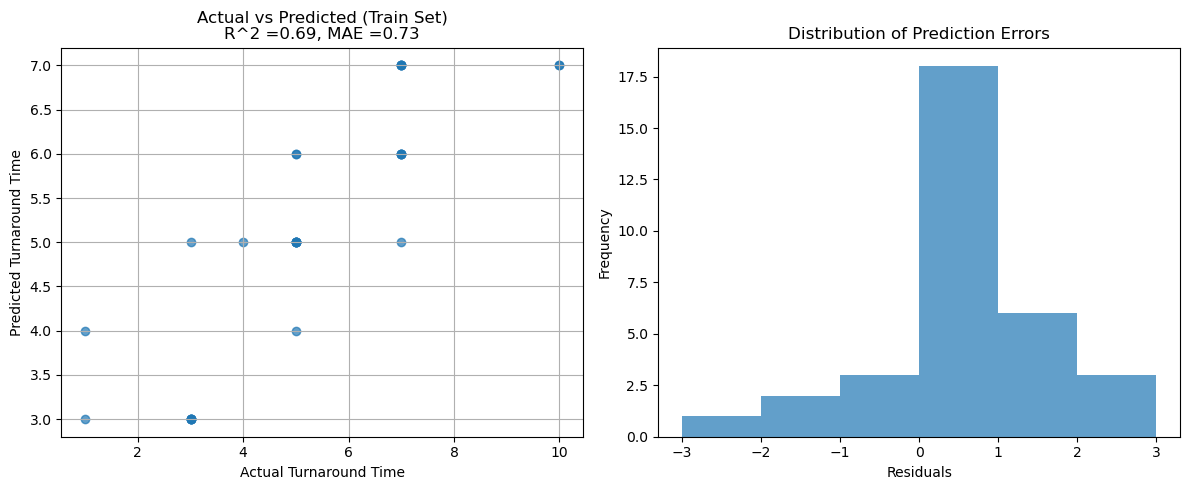

In [65]:
plt.figure(figsize=(12,5))

# Actual vs Predicted
plt.subplot(1,2,1)
plt.scatter(x=y_train, y=y_train_pred_round, alpha=0.7)
plt.xlabel("Actual Turnaround Time")
plt.ylabel("Predicted Turnaround Time")
plt.title(f"Actual vs Predicted (Train Set)\nR^2 ={r2_train:.2f}, MAE ={mae_train:.2f}")
plt.grid(True)

# Residual Distribution
plt.subplot(1,2,2)
residuals = y_train - y_train_pred_round
plt.hist(residuals, bins=6, alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

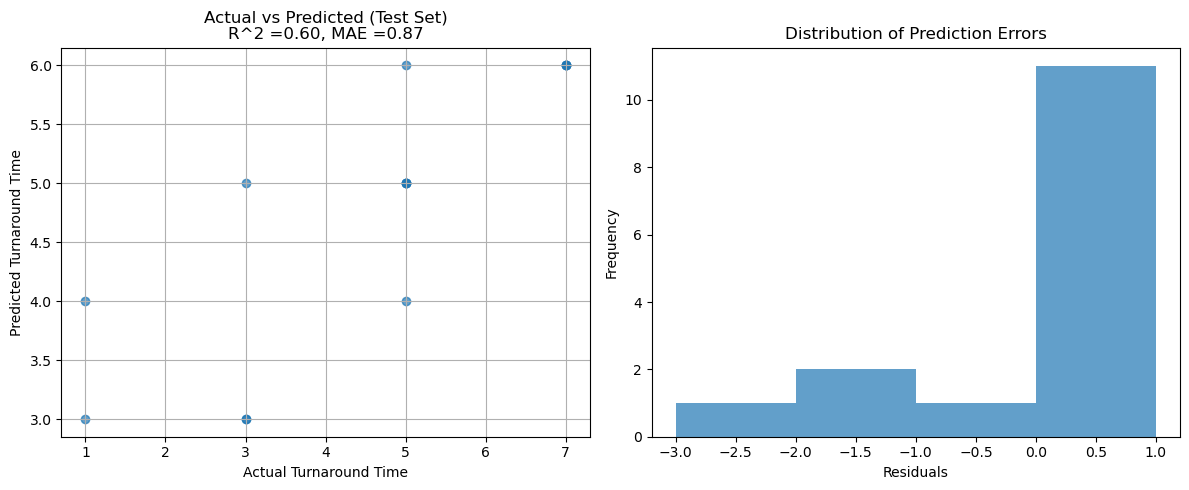

In [67]:
plt.figure(figsize=(12,5))

# Actual vs Predicted
plt.subplot(1,2,1)
plt.scatter(x=y_test, y=y_test_pred_round, alpha=0.7)
plt.xlabel("Actual Turnaround Time")
plt.ylabel("Predicted Turnaround Time")
plt.title(f"Actual vs Predicted (Test Set)\nR^2 ={r2_test:.2f}, MAE ={mae_test:.2f}")
plt.grid(True)

# Residual Distribution
plt.subplot(1,2,2)
residuals = y_test - y_test_pred_round
plt.hist(residuals, bins=4, alpha=0.7)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()